In [38]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
# allow importing the "backbone" package when the kernel's cwd is noteonooks/
sys.path.append(os.path.abspath(".."))
import backbone.custom_metrics.AstroMLmod3 as AstroMLmod
import backbone.custom_metrics.Intrinsic_dimension as id_module
from backbone.data_handle.Test import KNN_accuracy
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import davies_bouldin_score

# Test representations: TPCF & ID scores per epoch

In [39]:
import importlib
importlib.reload(AstroMLmod)
n_epochs = 10

tpcf_scores = []
tpcf_std_scores = []
id_scores = []
cosine_sim_scores = []
cosine_sim_std_scores = []
anisotropy_scores = []
davies_bouldin_scores = []
knn_accuracy_scores = []
knn_accuracy_std_scores = []

for epoch in range(n_epochs):
    pkl_filename = f"../Plots/Test_representations_labels{epoch}.csv"
    with open(pkl_filename, 'rb') as file:
        test_rep = pickle.load(file)

    representations = np.array(test_rep[0])
    labels = test_rep[1]
    n = representations.shape[0]

    # TPCF_score bootstraps over subsamples and returns (mean, std)
    tpcf, tpcf_std = AstroMLmod.TPCF_score(representations, epoch=epoch)
    id_ = id_module.id_score(representations)
    db_score = davies_bouldin_score(representations, labels)
    knn_acc, knn_acc_std = KNN_accuracy(representations, labels)

    # average pairwise cosine similarity, excluding self-similarity on the diagonal
    cos_sim_matrix = cosine_similarity(representations)
    off_diag_mask = ~np.eye(n, dtype=bool)
    avg_cos_sim = cos_sim_matrix[off_diag_mask].mean()
    std_cos_sim = cos_sim_matrix[off_diag_mask].std()

    # anisotropy: fraction of variance explained by the top singular direction
    centered = representations - representations.mean(axis=0, keepdims=True)
    singular_values = np.linalg.svd(centered, compute_uv=False)
    explained_variance = (singular_values ** 2) / (n - 1)
    explained_variance_ratio = explained_variance / explained_variance.sum()
    anisotropy = explained_variance_ratio[0]

    tpcf_scores.append(tpcf)
    tpcf_std_scores.append(tpcf_std)
    id_scores.append(id_)
    cosine_sim_scores.append(avg_cos_sim)
    cosine_sim_std_scores.append(std_cos_sim)
    anisotropy_scores.append(anisotropy)
    davies_bouldin_scores.append(db_score)
    knn_accuracy_scores.append(knn_acc)
    knn_accuracy_std_scores.append(knn_acc_std)

    print(f"Epoch {epoch}: TPCF={tpcf:.4f}±{tpcf_std:.4f} ID={id_} CosineSim={avg_cos_sim:.4f}±{std_cos_sim:.4f} Anisotropy={anisotropy:.4f} DaviesBouldin={db_score:.4f} KNNAcc={knn_acc:.2f}±{knn_acc_std:.2f}")


Epoch 0: TPCF=2.9100±7.8000 ID=(np.float64(52.84900851645983), np.float64(1.1351789783375381)) CosineSim=0.1953±0.1200 Anisotropy=0.9690 DaviesBouldin=12.2427 KNNAcc=19.62±0.36
Epoch 1: TPCF=258.9200±7.2500 ID=(np.float64(6.474349367928087), np.float64(0.18000987208329183)) CosineSim=0.8132±0.1050 Anisotropy=0.9935 DaviesBouldin=3.3405 KNNAcc=57.01±0.23
Epoch 2: TPCF=287.2200±5.1200 ID=(np.float64(5.476367738514467), np.float64(0.17627895792483997)) CosineSim=0.7730±0.1009 Anisotropy=0.1940 DaviesBouldin=2.1090 KNNAcc=69.99±0.43
Epoch 3: TPCF=245.9300±7.3200 ID=(np.float64(5.156514404021865), np.float64(0.13888320344486754)) CosineSim=0.7643±0.1002 Anisotropy=0.2050 DaviesBouldin=1.9558 KNNAcc=73.51±0.44
Epoch 4: TPCF=210.7900±5.1400 ID=(np.float64(4.926801321579964), np.float64(0.07243126118509365)) CosineSim=0.7541±0.0996 Anisotropy=0.1975 DaviesBouldin=1.4743 KNNAcc=77.23±0.20
Epoch 5: TPCF=193.2100±6.4200 ID=(np.float64(4.807979113003379), np.float64(0.19977770945142484)) CosineSim

In [40]:
results = pd.DataFrame({
    "epoch": range(n_epochs),
    "tpcf_score": tpcf_scores,
    "tpcf_std": tpcf_std_scores,
    "id_mean": [i[0] for i in id_scores],
    "id_std": [i[1] for i in id_scores],
    "avg_cosine_similarity": cosine_sim_scores,
    "cosine_similarity_std": cosine_sim_std_scores,
    "anisotropy": anisotropy_scores,
    "davies_bouldin": davies_bouldin_scores,
    "knn_accuracy": knn_accuracy_scores,
    "knn_accuracy_std": knn_accuracy_std_scores,
})

# keep pickle format for compatibility with existing plotting notebooks
with open("Test_TPCF_score.csv", "wb") as file:
    pickle.dump(tpcf_scores, file)

with open("Test_id_score.csv", "wb") as file:
    pickle.dump(id_scores, file)

results.to_csv("Test_TPCF_id_scores.csv", index=False)
results


,epoch,tpcf_score,tpcf_std,id_mean,id_std,avg_cosine_similarity,cosine_similarity_std,anisotropy,davies_bouldin,knn_accuracy,knn_accuracy_std
0,0,2.91,7.80,52.849009,1.135179,0.195290,0.120019,0.968971,12.242701,19.62,0.36
1,1,258.92,7.25,6.474349,0.180010,0.813158,0.105050,0.993488,3.340510,57.01,0.23
2,2,287.22,5.12,5.476368,0.176279,0.773033,0.100912,0.193982,2.108989,69.99,0.43
3,3,245.93,7.32,5.156514,0.138883,0.764261,0.100155,0.204972,1.955844,73.51,0.44
4,4,210.79,5.14,4.926801,0.072431,0.754089,0.099601,0.197458,1.474272,77.23,0.20
5,5,193.21,6.42,4.807979,0.199778,0.747335,0.101330,0.169507,1.409213,78.72,0.33
6,6,204.96,5.12,4.729992,0.258681,0.742658,0.100285,0.168619,1.374974,79.65,0.39
7,7,191.66,5.83,4.415906,0.152517,0.730413,0.104763,0.214304,1.374315,80.52,0.32
8,8,178.16,5.09,4.532437,0.155342,0.727543,0.103916,0.177570,1.361703,79.92,0.35
9,9,167.90,5.21,4.097617,0.110171,0.726584,0.105263,0.178251,1.323658,80.64,0.46


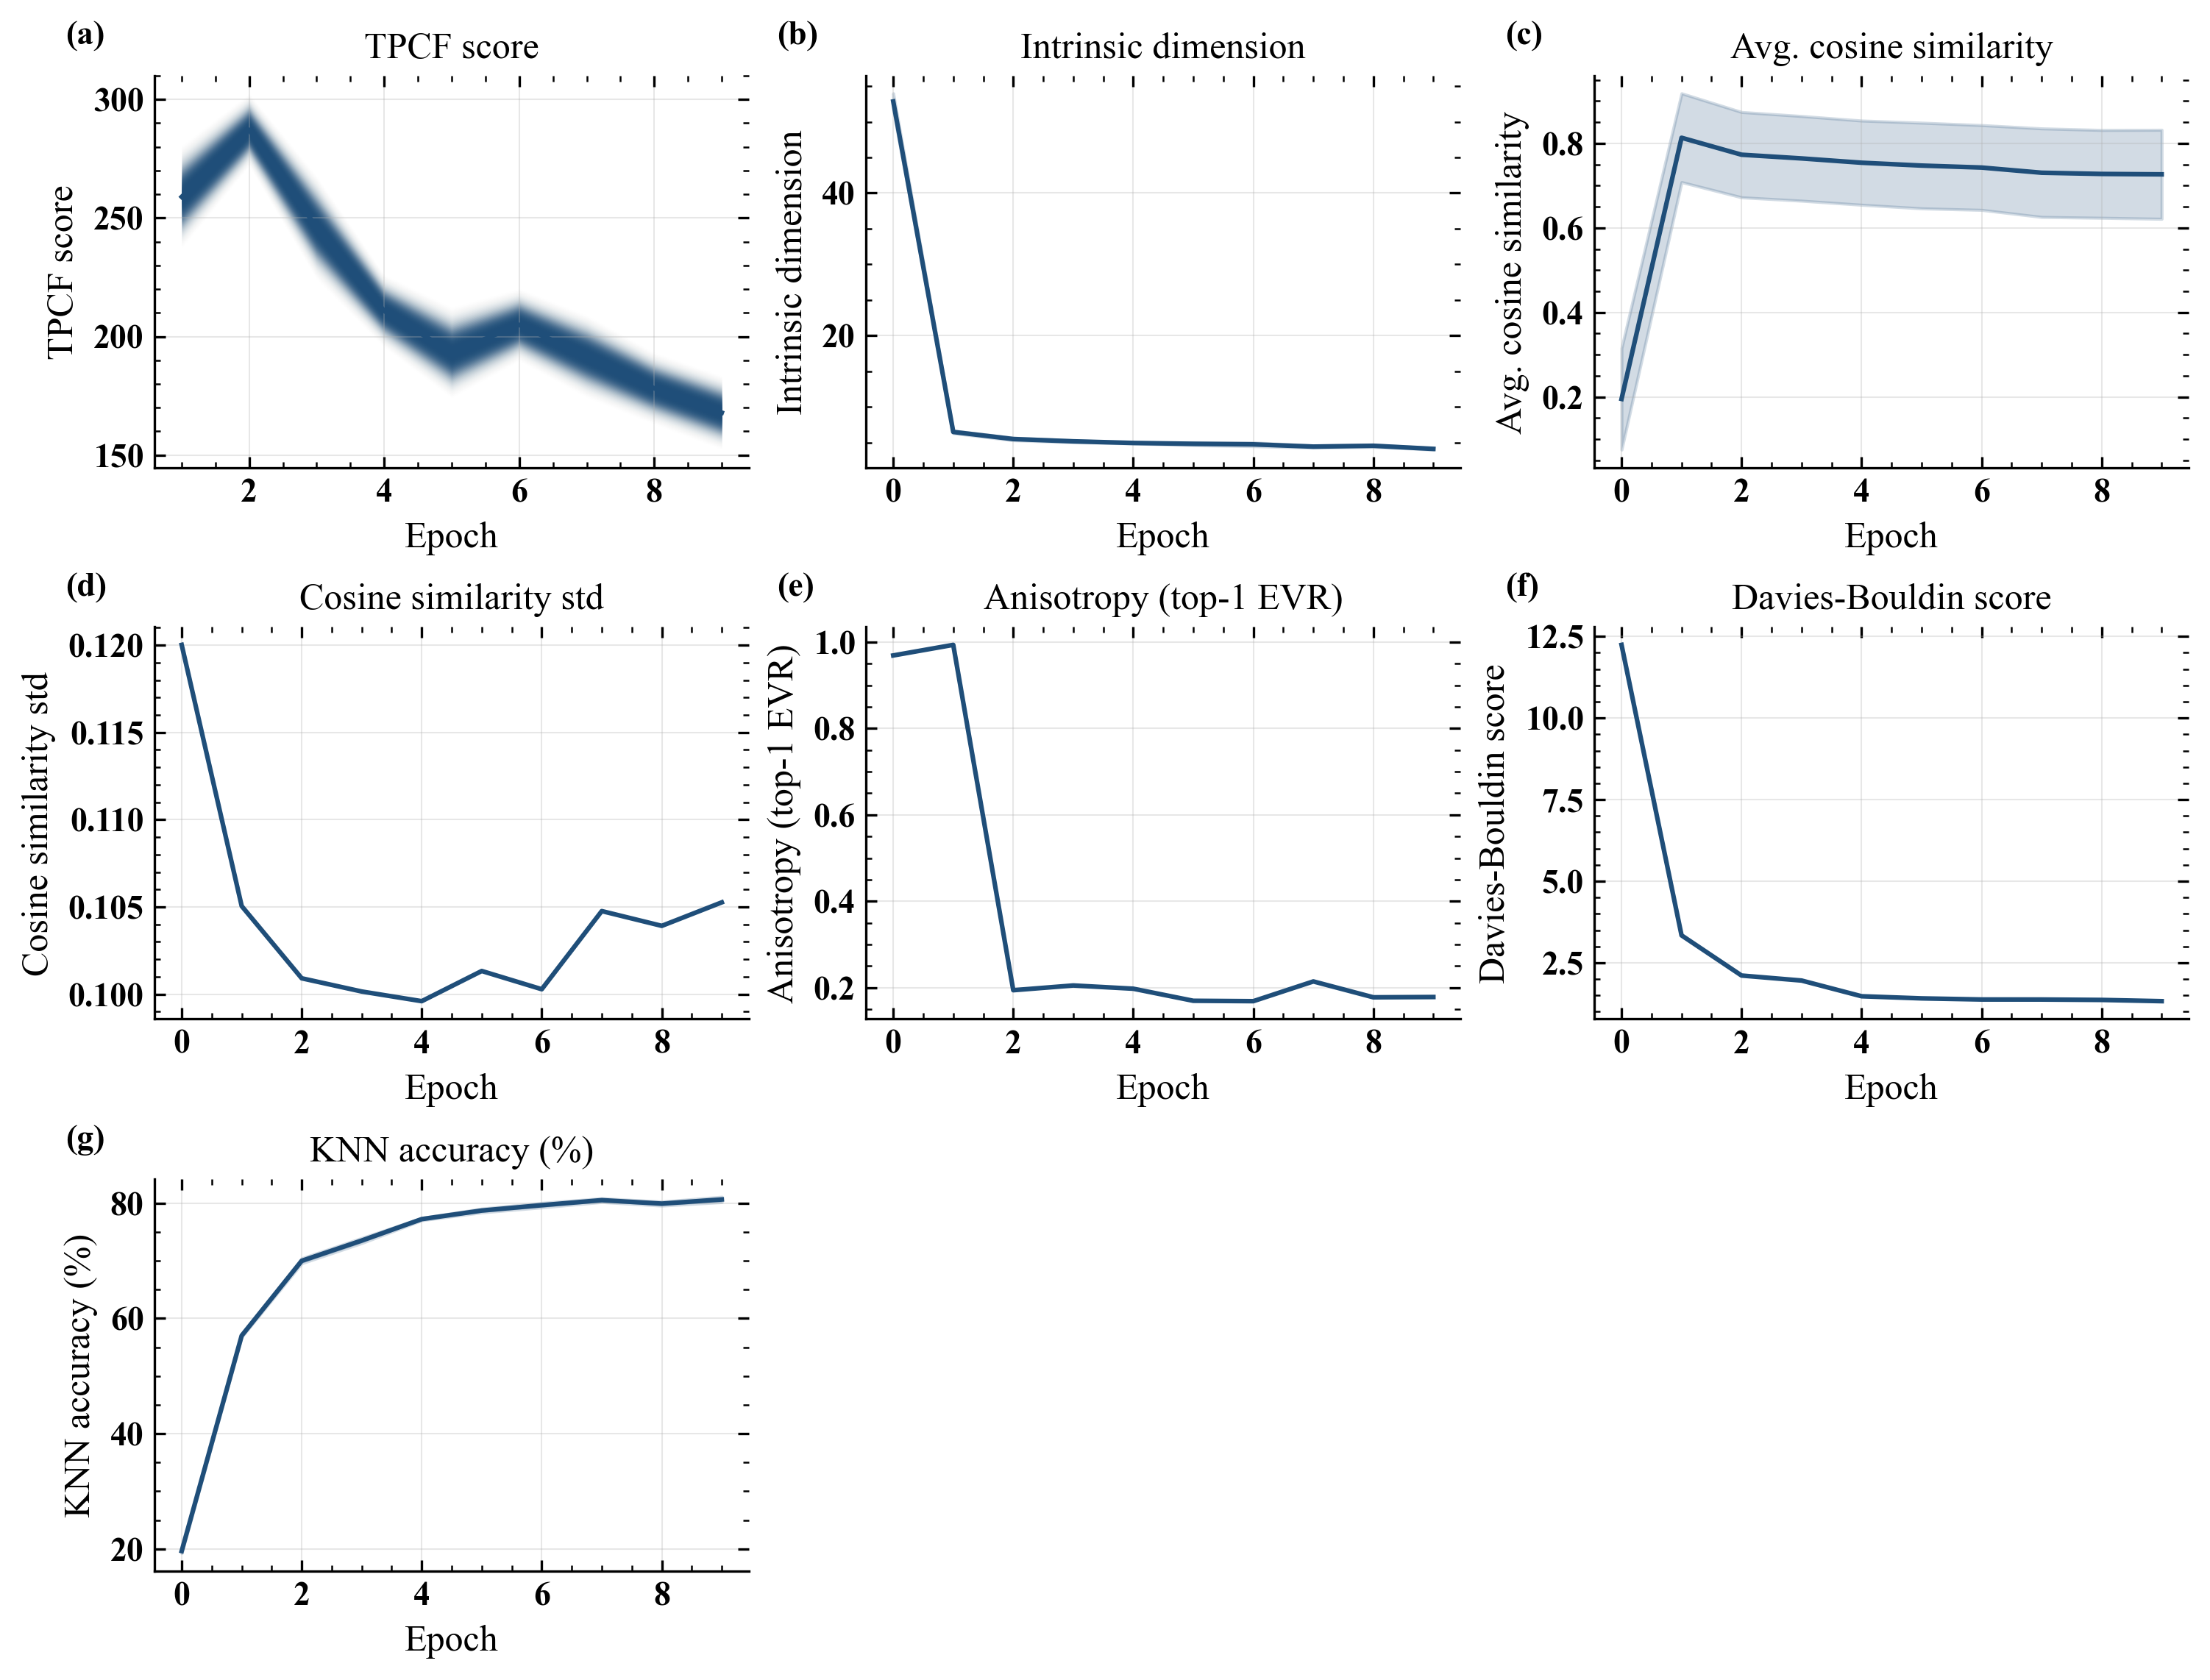

In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import string

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
})

ACCENT = "#1f4e79"

metrics = [
    ("tpcf_score", "TPCF score", "tpcf_std"),
    ("id_mean", "Intrinsic dimension", "id_std"),
    ("avg_cosine_similarity", "Avg. cosine similarity", "cosine_similarity_std"),
    ("cosine_similarity_std", "Cosine similarity std", None),
    ("anisotropy", "Anisotropy (top-1 EVR)", None),
    ("davies_bouldin", "Davies-Bouldin score", None),
    ("knn_accuracy", "KNN accuracy (%)", "knn_accuracy_std"),
]


def plot_gradient_band(ax, x, y, y_err, color=ACCENT, n_layers=40, max_sigma=3.0):
    """Shade the uncertainty band with an alpha gradient that fades away from the mean."""
    x = np.asarray(x)
    y = np.asarray(y)
    y_err = np.asarray(y_err)
    sigmas = np.linspace(max_sigma / n_layers, max_sigma, n_layers)
    for sigma in sigmas[::-1]:
        alpha = 0.35 * np.exp(-0.5 * sigma ** 2)
        ax.fill_between(x, y - sigma * y_err, y + sigma * y_err, color=color, alpha=alpha, linewidth=0)


n_cols = 3
n_rows = -(-len(metrics) // n_cols)  # ceil division

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(3.3 * n_cols, 2.5 * n_rows), squeeze=False, constrained_layout=True
)
axes = axes.flatten()

for panel_label, ax, (col, title, err_col) in zip(string.ascii_lowercase, axes, metrics):
    # epoch 0 TPCF is dominated by a single outlier representation, so skip it
    data = results.iloc[1:] if col == "tpcf_score" else results
    ax.plot(data["epoch"], data[col], color=ACCENT)
    if col == "tpcf_score":
        plot_gradient_band(ax, data["epoch"], data[col], data[err_col])
    elif err_col is not None:
        ax.fill_between(
            data["epoch"],
            data[col] - data[err_col],
            data[col] + data[err_col],
            color=ACCENT,
            alpha=0.2,
        )
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.text(-0.15, 1.08, f"({panel_label})", transform=ax.transAxes, fontsize=11, fontweight="bold")

# hide any unused axes in the grid
for ax in axes[len(metrics):]:
    ax.axis("off")

fig.savefig("Test_metrics_grid.pdf", bbox_inches="tight")
fig.savefig("Test_metrics_grid.png", bbox_inches="tight")
plt.show()